# EfficientDet Training On A Custom Dataset



<table align="left"><td>
  <a target="_blank"  href="https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/blob/master/tutorial/train_shape.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on github
  </a>
</td><td>
  <a target="_blank"  href="https://colab.research.google.com/github/zylo117/Yet-Another-EfficientDet-Pytorch/blob/master/tutorial/train_shape.ipynb">
    <img width=32px src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
</td></table>

## This tutorial will show you how to train a custom dataset.

## For the sake of simplicity, I generated a dataset of different shapes, like rectangles, triangles, circles.

## Please enable GPU support to accelerate on notebook setting if you are using colab.

### 0. Install Requirements

In [1]:
!git clone https://github.com/tristandb/EfficientDet-PyTorch.git


Cloning into 'EfficientDet-PyTorch'...
remote: Enumerating objects: 216, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 216 (delta 8), reused 8 (delta 3), pack-reused 195 (from 1)
Receiving objects: 100% (216/216), 91.77 MiB | 15.86 MiB/s, done.
Resolving deltas: 100% (105/105), done.


### 1. Prepare Custom Dataset/Pretrained Weights (Skip this part if you already have datasets and weights of your own)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
!pip install efficientnet_pytorch


In [14]:
!pip install ptflops


In [9]:
!pip show efficientnet_pytorch


Name: efficientnet_pytorch
Version: 0.7.1
Summary: EfficientNet implemented in PyTorch.
Home-page: https://github.com/lukemelas/EfficientNet-PyTorch
Author: Luke
Author-email: lmelaskyriazi@college.harvard.edu
License: Apache
Location: /usr/local/lib/python3.11/dist-packages
Requires: torch
Required-by: 


In [17]:
import re

# Buka isi train.py
with open('/content/EfficientDet-PyTorch/train.py', 'r') as f:
    code = f.read()

# Ganti path COCO (misalnya: /content/drive/MyDrive/mangrove/)
new_path = '/content/drive/MyDrive/mangrove'

# Cari baris seperti: dataset_train = CocoDataset(parser.coco_path ...
code = re.sub(
    r"CocoDataset\(parser\.coco_path, set_name='train2017'",
    f"CocoDataset('{new_path}', set_name='train'",
    code
)

code = re.sub(
    r"CocoDataset\(parser\.coco_path, set_name='val2017'",
    f"CocoDataset('{new_path}', set_name='valid'",
    code
)

# Simpan kembali
with open('/content/EfficientDet-PyTorch/train.py', 'w') as f:
    f.write(code)

print("Path berhasil diperbarui.")


Path berhasil diperbarui.


In [23]:
!python /content/EfficientDet-PyTorch/train.py --dataset coco \
  --coco_path /content/drive/MyDrive/mangrove \
  --efficientdet \
  --batch-size 2 \
  --scaling-compound 0 \
  --epochs 10 \
  --print-model-complexity


CUDA available: True
loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Loaded pretrained weights for efficientnet-b0
DataParallel(
  913.49 k, 45.479% Params, 3.74 GMac, 99.608% MACs, 
  (module): EfficientDet(
    913.49 k, 45.479% Params, 3.74 GMac, 99.608% MACs, 
    (efficientnet): Sequential(
      19.23 k, 0.957% Params, 64.57 MMac, 1.719% MACs, 
      (0): Conv2dStaticSamePadding(
        0, 0.000% Params, 0.0 Mac, 0.0

In [48]:
# import os
# import sys
# if "projects" not in os.getcwd():
#   !git clone --depth 1 https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch
#   os.chdir('Yet-Another-EfficientDet-Pytorch')
#   sys.path.append('.')
# else:
#   !git pull

# # download and unzip dataset
# ! mkdir datasets
# ! wget https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.1/dataset_shape.tar.gz
# ! tar xzf dataset_shape.tar.gz

# # download pretrained weights
# ! mkdir weights
# ! wget https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.0/efficientdet-d0.pth -O weights/efficientdet-d0.pth

# # prepare project file projects/shape.yml
# # showing its contents here
# ! cat projects/shape.yml

#codegpt
import os
import sys

# Clone repo jika belum ada
if "projects" not in os.getcwd():
    !git clone --depth 1 https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch
    os.chdir('Yet-Another-EfficientDet-Pytorch')
    sys.path.append('.')
else:
    !git pull



Cloning into 'Yet-Another-EfficientDet-Pytorch'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 47 (delta 2), reused 33 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 5.67 MiB | 25.78 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [49]:
# Buat folder dataset
#!mkdir -p datasets/roboflow_dataset

# Unduh dataset dari Roboflow (COCO Format)
!curl -L "https://app.roboflow.com/ds/yD0w0T1dhu?key=8CzjqtI1Sj" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip
!unzip -q roboflow.zip -d datasets/roboflow_dataset

!mkdir -p datasets/shape/annotations
!cp datasets/roboflow_dataset/train/_annotations.coco.json datasets/shape/annotations/instances_train.json
!cp datasets/roboflow_dataset/valid/_annotations.coco.json datasets/shape/annotations/instances_val.json





  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   901  100   901    0     0   2982      0 --:--:-- --:--:-- --:--:--  2983
100  116M  100  116M    0     0  20.6M      0  0:00:05  0:00:05 --:--:-- 26.4M
Archive:  roboflow.zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
  inflating: test/_annotations.coco.json  
 extracting: test/id_123_png.rf.b4b6007ca67566ee2905a87ce4aee41b.jpg  
 extracting: test/id_126_png.rf.462e1b7915c2767ca0cd05605d2ecf75.jpg  
 extracting: test/id_175_png.rf.739881eb9a305ce00a35515cddcd5f84.jpg  
 extracting: test/id_190_png.rf.79bd0daacbd9fc3629527af490488279.jpg  
 extracting: test/id_194_png.rf.5f6ce68c59d7141f0b0d82877f4840a4.jpg  
 extracting: test/id_221_png.rf.f21ab8b67d1ce9e0dd38e29484bd9957.jpg  
 extracting: test/id_225_png.rf.580666bcd018aacc953aed45c3b7dd42.jpg  
 extracting: test/id_237_png.rf.4f65b4b7183db

In [50]:
%%writefile projects/roboflow.yml
project_name: roboflow_dataset
train_set: /content/drive/MyDrive/mangrove/anotasi/anotasitrain.json
val_set: /content/drive/MyDrive/mangrove/anotasi/anotasivalid.json
test_set: /content/drive/MyDrive/mangrove/anotasi/anotasitest.json
num_classes: 3  # ganti sesuai jumlah kelas



Writing projects/roboflow.yml


### 2. Training

In [51]:
!pip install tensorboardX


In [55]:
# consider this is a simple dataset, train head will be enough.
! python train.py -c 0 -p roboflow_dataset --head_only True --lr 1e-3 --batch_size 32 --load_weights weights/efficientdet-d0.pth  --num_epochs 50 --save_interval 100

# the loss will be high at first
# don't panic, be patient,
# just wait for a little bit longer

Traceback (most recent call last):
  File "/content/Yet-Another-EfficientDet-Pytorch/Yet-Another-EfficientDet-Pytorch/Yet-Another-EfficientDet-Pytorch/train.py", line 326, in <module>
    train(opt)
  File "/content/Yet-Another-EfficientDet-Pytorch/Yet-Another-EfficientDet-Pytorch/Yet-Another-EfficientDet-Pytorch/train.py", line 85, in train
    params = Params(f'projects/{opt.project}.yml')
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Yet-Another-EfficientDet-Pytorch/Yet-Another-EfficientDet-Pytorch/Yet-Another-EfficientDet-Pytorch/train.py", line 28, in __init__
    self.params = yaml.safe_load(open(project_file).read())
                                 ^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'projects/roboflow_dataset.yml'


### 3. Evaluation

In [ ]:
#get latest weight file
%cd logs/shape
weight_file = !ls -Art | grep efficientdet
%cd ../..

#uncomment the next line to specify a weight file
#weight_file[-1] = 'efficientdet-d0_49_1400.pth'

! python coco_eval.py -c 0 -p shape -w "logs/shape/{weight_file[-1]}"

running coco-style evaluation on project shape, weights logs/shape/efficientdet-d0_49_1400.pth...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 100/100 [00:08<00:00, 11.80it/s]
Loading and preparing results...
DONE (t=0.63s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.46s).
Accumulating evaluation results...
DONE (t=0.14s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.781
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.947
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.868
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.794
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.740
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.470
 Av

### 4. Visualize

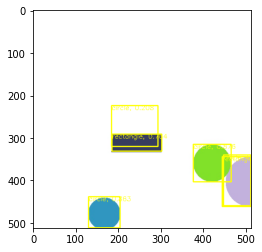

In [ ]:
import torch
from torch.backends import cudnn

from backbone import EfficientDetBackbone
import cv2
import matplotlib.pyplot as plt
import numpy as np

from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, invert_affine, postprocess

compound_coef = 0
force_input_size = None  # set None to use default size
img_path = 'datasets/shape/val/999.jpg'

threshold = 0.2
iou_threshold = 0.2

use_cuda = True
use_float16 = False
cudnn.fastest = True
cudnn.benchmark = True

obj_list = ['rectangle', 'circle']

# tf bilinear interpolation is different from any other's, just make do
input_sizes = [512, 640, 768, 896, 1024, 1280, 1280, 1536]
input_size = input_sizes[compound_coef] if force_input_size is None else force_input_size
ori_imgs, framed_imgs, framed_metas = preprocess(img_path, max_size=input_size)

if use_cuda:
    x = torch.stack([torch.from_numpy(fi).cuda() for fi in framed_imgs], 0)
else:
    x = torch.stack([torch.from_numpy(fi) for fi in framed_imgs], 0)

x = x.to(torch.float32 if not use_float16 else torch.float16).permute(0, 3, 1, 2)

model = EfficientDetBackbone(compound_coef=compound_coef, num_classes=len(obj_list),

                             # replace this part with your project's anchor config
                             ratios=[(1.0, 1.0), (1.4, 0.7), (0.7, 1.4)],
                             scales=[2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)])

model.load_state_dict(torch.load('logs/shape/'+weight_file[-1]))
model.requires_grad_(False)
model.eval()

if use_cuda:
    model = model.cuda()
if use_float16:
    model = model.half()

with torch.no_grad():
    features, regression, classification, anchors = model(x)

    regressBoxes = BBoxTransform()
    clipBoxes = ClipBoxes()

    out = postprocess(x,
                      anchors, regression, classification,
                      regressBoxes, clipBoxes,
                      threshold, iou_threshold)

out = invert_affine(framed_metas, out)

for i in range(len(ori_imgs)):
    if len(out[i]['rois']) == 0:
        continue
    ori_imgs[i] = ori_imgs[i].copy()
    for j in range(len(out[i]['rois'])):
        (x1, y1, x2, y2) = out[i]['rois'][j].astype(np.int)
        cv2.rectangle(ori_imgs[i], (x1, y1), (x2, y2), (255, 255, 0), 2)
        obj = obj_list[out[i]['class_ids'][j]]
        score = float(out[i]['scores'][j])

        cv2.putText(ori_imgs[i], '{}, {:.3f}'.format(obj, score),
                    (x1, y1 + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255, 255, 0), 1)

        plt.imshow(ori_imgs[i])

